In [1]:
import pandas as pd
import numpy as np
import mne

In [140]:
eeg_df = pd.read_csv("offline_2back_sham.csv")
full_eeg_df = pd.read_csv("offline_2back_sham.csv")
full_eeg_df.drop(['Time', ' Ch08'], axis = 1, inplace = True)
full_eeg_df

,Ch01,Ch02,Ch03,Ch04,Ch05,Ch06,Ch07
0,-43745.968750,-90054.648438,-96530.523438,2154.469971,-90810.164062,-44963.605469,-43845.519531
1,-45293.335938,-89654.046875,-96594.414062,1629.781860,-90186.773438,-46047.710938,-45723.730469
2,-46425.656250,-90015.875000,-96968.726562,1299.262329,-90561.851562,-46726.898438,-46250.636719
3,-44949.582031,-90330.125000,-96877.984375,1767.635498,-91075.812500,-45698.292969,-44528.730469
4,-43675.398438,-90129.226562,-96554.187500,2179.026855,-90943.046875,-44899.230469,-43664.863281
...,...,...,...,...,...,...,...
49740,-60765.843750,-102492.601562,-111593.539062,-15888.333984,-105135.234375,-59842.738281,-59195.761719
49741,-60548.886719,-102734.859375,-111708.984375,-15843.250000,-105367.562500,-59828.687500,-59246.167969
49742,-60606.648438,-101624.109375,-111095.851562,-15986.396484,-103994.960938,-59968.957031,-60424.593750
49743,-60808.875000,-101210.960938,-110888.273438,-16054.989258,-103558.046875,-60003.781250,-60565.480469


In [131]:
markers = pd.read_csv("lifu_markers_1_2back_sham.csv")
lifu_on = markers[markers["marker"]=="LIFU_ON"].copy()
lifu_on_time_onset = np.array(lifu_on['Time'])
lifu_on_time_onset

array([ 57.0829887,  72.7382817,  87.748421 , 103.0673615, 118.5132294,
       155.2029245, 175.6946256, 191.4040139])

In [129]:
lifu_on

,Time,marker,LSL_timestamp
202,57.082989,LIFU_ON,898868.251219
204,72.738282,LIFU_ON,898883.906512
206,87.748421,LIFU_ON,898898.916652
208,103.067361,LIFU_ON,898914.235592
210,118.513229,LIFU_ON,898929.681460
212,155.202924,LIFU_ON,898966.371155
214,175.694626,LIFU_ON,898986.862856
216,191.404014,LIFU_ON,899002.572245


Creating RawArray with float64 data, n_channels=7, n_times=49745
    Range : 0 ... 49744 =      0.000 ...   198.976 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz



C:\Users\jshin\AppData\Local\Temp\ipykernel_2240\4072443047.py:15: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill').fillna(method='ffill')


FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 825 samples (3.300 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- F

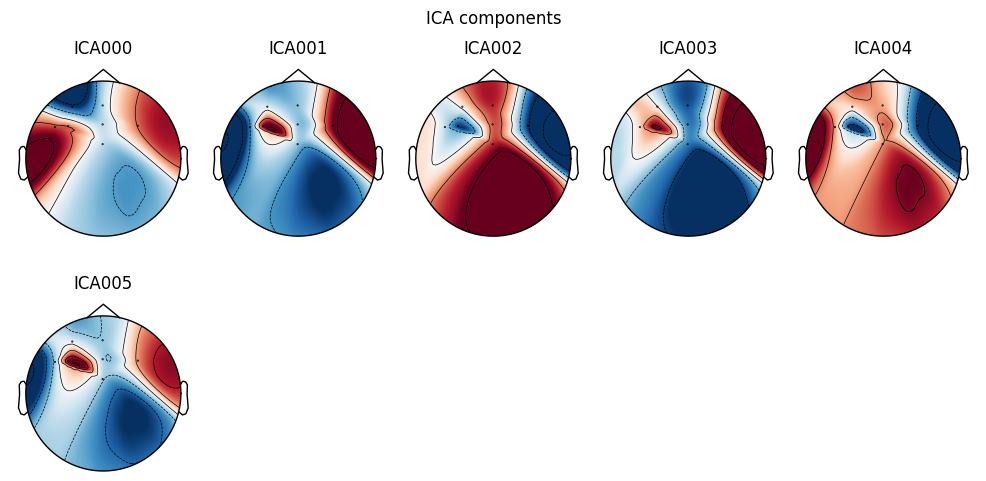

Creating RawArray with float64 data, n_channels=6, n_times=49745
    Range : 0 ... 49744 =      0.000 ...   198.976 secs
Ready.


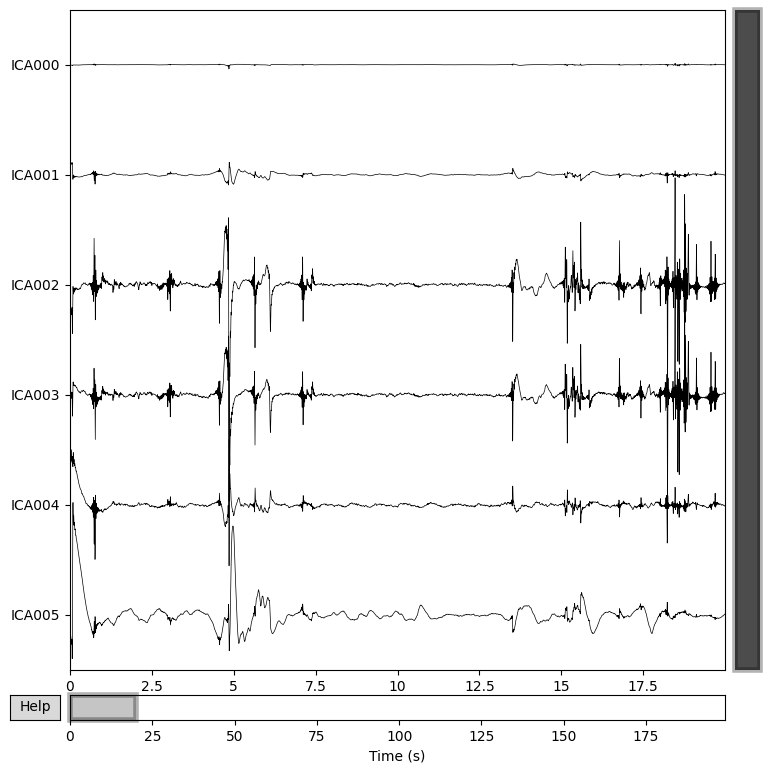

Applying ICA to Raw instance
    Transforming to ICA space (6 components)
    Zeroing out 2 ICA components
    Projecting back using 7 PCA components
Effective window size : 2.048 (s)
  Channel  Theta (4–7 Hz)  Alpha (8–12 Hz)  Beta (13–30 Hz)  Gamma (30–40 Hz)
0      Fz     4464.339355      4260.119851      4387.304245       3595.477391
1     FC3     6722.882636      5404.179295      6366.904271       6642.556750
2     FC5      784.869811       804.781027       586.673212        514.975854
3      F3       60.157082        25.962492        35.195396         87.737496
4     FC4     6992.245553      6433.704211      7120.250350       6591.419046
5     FCz     2956.822238      2754.235507      3011.808708       2711.410152
6      Cz     3919.486645      3598.607018      3742.662597       3207.391140


<Figure size 1200x600 with 0 Axes>

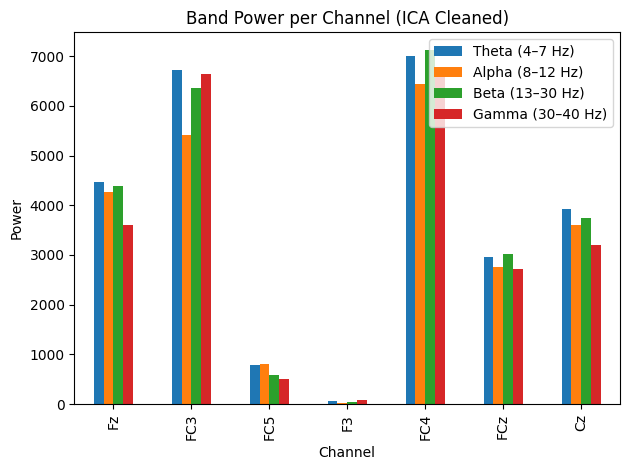

In [118]:
import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt

# first_data: rows = samples, columns = 8 EEG channels
# 1. Clean and Load Data

df = pd.DataFrame(full_eeg_df.copy())
df = df.replace([np.inf, -np.inf], np.nan)
df = df.replace(-200000.0, np.nan)
threshold = len(df) * 0.5
df = df.dropna(thresh=threshold, axis=1)
df = df.interpolate(method='linear', limit=5, limit_direction='both')
df = df.fillna(method='bfill').fillna(method='ffill')

# 2. MNE Array Building
sfreq = 250
data = df.values.T  # shape: (n_channels, n_samples)

# Mapping --> make it less manual
ch_names = [
    "Fz",   # 1
    "FC3",   # 2
    "FC5",  # 3
    "F3",   # 4
    "FC4",   # 5
    "FCz",  # 6
    "Cz",  # 7
    #"F5"    # 8
]

info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')
raw = mne.io.RawArray(data, info)

# 3. ICA topography
montage = mne.channels.make_standard_montage("standard_1020")
raw.set_montage(montage)

# 4. Filtering
# 1–40 Hz is a good compromise for ICA + PSD
raw.filter(1., 40., fir_design='firwin')
raw.notch_filter(60.)
raw.filter(l_freq=1.0, h_freq=40.0, method='fir', fir_window='hamming')
raw.set_eeg_reference('average')

# 5. ICA
ica = mne.preprocessing.ICA(
    n_components= 0.99999,
    random_state=97,
    max_iter='auto'
)
ica.fit(raw)

# Inspect components:
ica.plot_components()      # scalp maps
ica.plot_sources(raw)      # time series

# After inspecting, set the components you want to remove:
ica.exclude = [0,1]  # don't know how to do this
raw_clean = ica.apply(raw.copy())

# 6. PSDs
psds, freqs = raw_clean.compute_psd(
    fmin=2,
    fmax=40,
    n_fft=512
).get_data(return_freqs=True)

# 7. Bandpower
def band_power(psds, freqs, fmin, fmax):
    mask = (freqs >= fmin) & (freqs <= fmax)
    return psds[:, mask].mean(axis=1)

theta = band_power(psds, freqs, 4, 7)
alpha = band_power(psds, freqs, 8, 12)
beta  = band_power(psds, freqs, 13, 30)
gamma = band_power(psds, freqs, 30, 40)

# 8. Plotting
bands_df = pd.DataFrame({
    'Channel': ch_names,
    'Theta (4–7 Hz)': theta,
    'Alpha (8–12 Hz)': alpha,
    'Beta (13–30 Hz)': beta,
    'Gamma (30–40 Hz)': gamma
})

print(bands_df)

plt.figure(figsize=(12, 6))
bands_df.set_index('Channel').plot(kind='bar')
plt.ylabel('Power')
plt.title('Band Power per Channel (ICA Cleaned)')
plt.tight_layout()
plt.show()


In [119]:
len(data[0])

49745

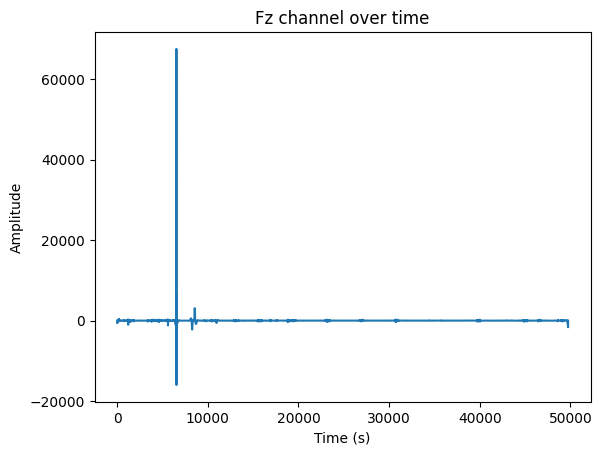

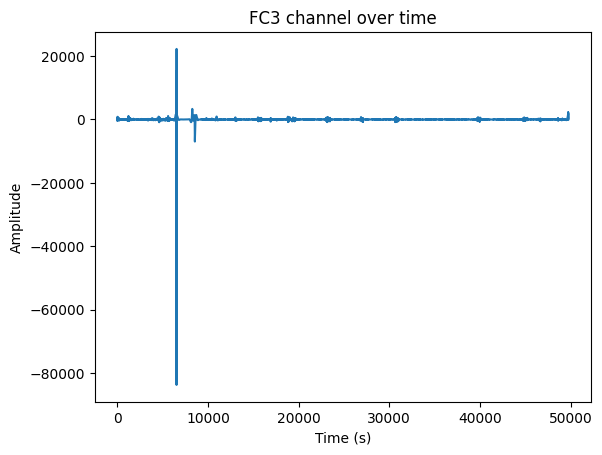

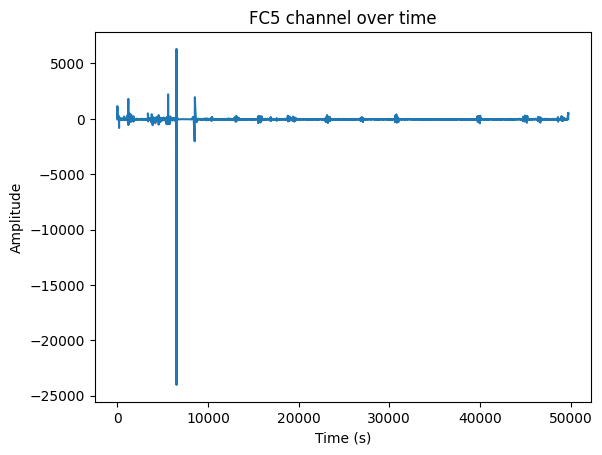

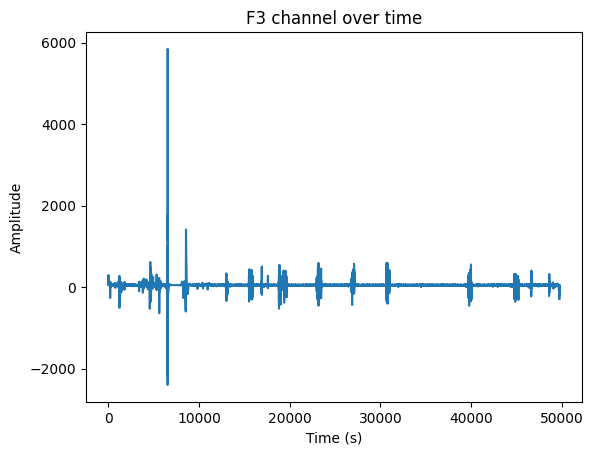

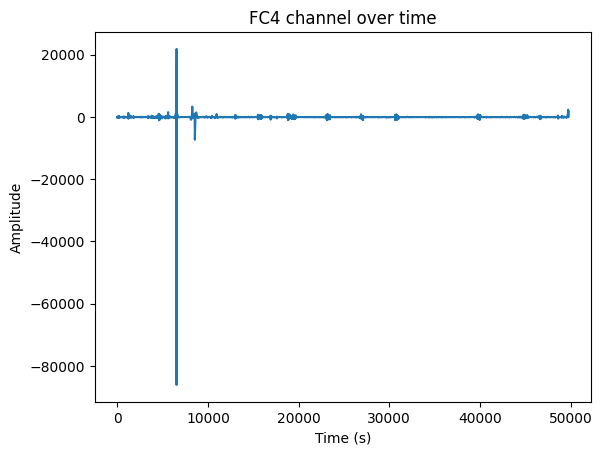

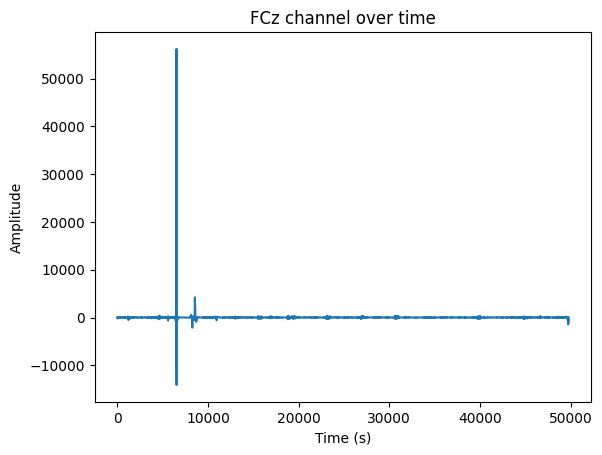

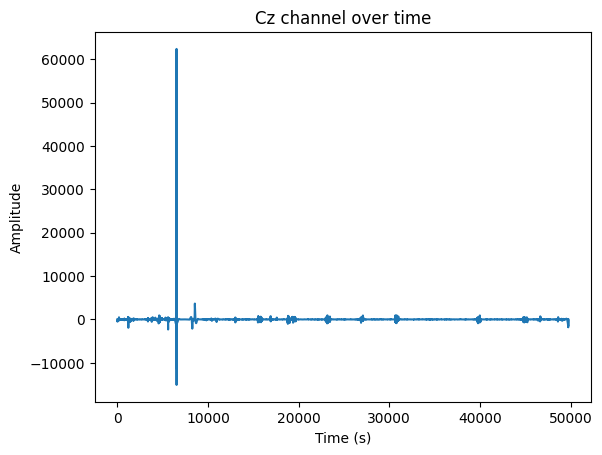

In [120]:
data = raw_clean.get_data()
for channel in raw.ch_names:
    channel_idx = raw.ch_names.index(channel)
    time_data = np.arange(0, 20, 1/250)  # adjust 500 to your sampling rate
    plt.plot( data[channel_idx])
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.title(f'{channel} channel over time')
    plt.show()

In [121]:
theta_pow = band_power(psds, freqs, 4, 7)
alpha_pow = band_power(psds, freqs, 8, 12)
theta_alpha_ratio = theta_pow / alpha_pow
theta_alpha_ratio

array([1.0479375 , 1.24401547, 0.97525884, 2.31707654, 1.08681489,
       1.07355461, 1.08916773])

In [122]:
import numpy as np

# amplitude threshold (µV)
amp_thresh = 150  # tweak as needed
eeg_filt = raw_clean.get_data().T
bad_amp = np.any(np.abs(eeg_filt) > amp_thresh, axis=1)

# gradient threshold (sudden jumps)
grad = np.diff(eeg_filt, axis=0, prepend=eeg_filt[[0], :])
grad_thresh = 50  # µV per sample
bad_grad = np.any(np.abs(grad) > grad_thresh, axis=1)

bad_samples = bad_amp | bad_grad


In [147]:
lifu_on

,Time,marker,LSL_timestamp
202,57.082989,LIFU_ON,898868.251219
204,72.738282,LIFU_ON,898883.906512
206,87.748421,LIFU_ON,898898.916652
208,103.067361,LIFU_ON,898914.235592
210,118.513229,LIFU_ON,898929.681460
212,155.202924,LIFU_ON,898966.371155
214,175.694626,LIFU_ON,898986.862856
216,191.404014,LIFU_ON,899002.572245


Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).


C:\Users\jshin\AppData\Local\Programs\Python\Python310\lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


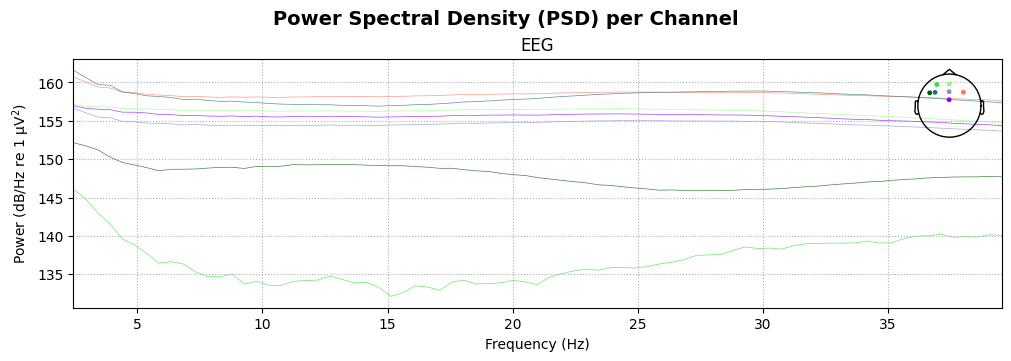

In [123]:
spectrum = raw_clean.compute_psd(fmin=2, fmax=40, n_fft=512)

# Plot the spectrum across all channels
fig = spectrum.plot(picks='all', spatial_colors=True, exclude='bads')

# Adjust the plot title and layout
fig.suptitle('Power Spectral Density (PSD) per Channel', fontsize=14, weight='bold')
plt.show()

In [209]:
def rebuild_clean_df_and_window(raw_clean, original_df, event_times, pre=2, post=10):
    """
    raw_clean: your preprocessed MNE Raw object (filtered, ICA-cleaned, reref)
    original_df: the original pandas EEG dataframe with the 'Time' column
    event_times: list/array of absolute LSL timestamps (e.g., LIFU onset times)
    pre, post: window lengths in seconds
    """

    import numpy as np
    import pandas as pd

    data = raw_clean.get_data().T   # shape (n_samples, n_channels)
    sfreq = raw_clean.info['sfreq']
    n_samples = data.shape[0]

    # original_df["Time"].iloc[0] = absolute LSL timestamp of sample 0
    t0 = original_df["Time"].iloc[0]
    time_axis = t0 + np.arange(n_samples) / sfreq

    ch_names = raw_clean.info['ch_names']
    clean_df = pd.DataFrame(data, columns=ch_names)
    clean_df["Time"] = time_axis

    windows = []

    for idx, event in enumerate(event_times):
        mask = (clean_df["Time"] >= (event - pre)) & (clean_df["Time"] <= (event + post))
        window_df = clean_df.loc[mask].copy()

        # Add relative time and index
        window_df["t_rel"] = window_df["Time"] - event
        window_df["idx"] = idx

        windows.append(window_df)

    return clean_df, windows
clean_df, raw_windows = rebuild_clean_df_and_window(
    raw_clean=raw_clean,
    original_df=eeg_df,
    event_times=lifu_on_time_onset,
    pre=2,
    post=10
)

# Example: inspect window 1
raw_windows[0]

,Fz,FC3,FC5,F3,FC4,FCz,Cz,Time,t_rel,idx
13771,-5.807507,-8.258651,-22.031622,48.835922,-3.627073,-1.955972,-7.155097,55.084,-1.998989,0
13772,-6.892989,-3.052124,-22.786043,46.271038,1.624142,-4.120144,-11.043880,55.088,-1.994989,0
13773,-7.735389,-1.471990,-23.068452,46.082496,3.099000,-5.045457,-11.860208,55.092,-1.990989,0
13774,-8.166229,-3.859898,-22.493849,48.109940,0.745247,-4.560335,-9.774876,55.096,-1.986989,0
13775,-8.790371,-6.731688,-21.533605,50.452483,-1.755649,-4.099156,-7.542014,55.100,-1.982989,0
...,...,...,...,...,...,...,...,...,...,...
16766,17.092317,-27.280376,-41.240664,48.236152,-21.870388,10.924830,14.138129,67.064,9.981011,0
16767,19.239586,-36.568400,-37.704878,51.446688,-30.665340,15.258937,18.993408,67.068,9.985011,0
16768,18.927441,-37.317720,-37.968319,52.464054,-31.379592,15.180642,20.093493,67.072,9.989011,0
16769,16.970345,-32.433183,-39.644861,51.406148,-26.161324,12.227612,17.635263,67.076,9.993011,0


In [180]:
base_dir_raw = r"C:\Users\jshin\OW_closedloopLIFU\eeg_windows\raw"
# MAKE SURE TO PUT IN NAME
new_folder_name = "sham1"
new_folder_path_raw = os.path.join(base_dir_raw, new_folder_name)
os.makedirs(new_folder_path_raw, exist_ok=False) # check

for idx, event in enumerate(raw_windows):
    # Build a unique filename for each event
    output_path_raw = os.path.join(new_folder_path_raw, f"{idx}_eeg_raw.csv")
    try:
        raw_windows[idx].to_csv(output_path_raw, index=False, encoding="utf-8")
        print(f"Saved successfully to: {output_path_raw}")
    except (OSError, IOError) as e:
        print(f"Error saving CSV file: {e}")

Saved successfully to: C:\Users\jshin\OW_closedloopLIFU\eeg_windows\raw\sham1\0_eeg_raw.csv
Saved successfully to: C:\Users\jshin\OW_closedloopLIFU\eeg_windows\raw\sham1\1_eeg_raw.csv
Saved successfully to: C:\Users\jshin\OW_closedloopLIFU\eeg_windows\raw\sham1\2_eeg_raw.csv
Saved successfully to: C:\Users\jshin\OW_closedloopLIFU\eeg_windows\raw\sham1\3_eeg_raw.csv
Saved successfully to: C:\Users\jshin\OW_closedloopLIFU\eeg_windows\raw\sham1\4_eeg_raw.csv
Saved successfully to: C:\Users\jshin\OW_closedloopLIFU\eeg_windows\raw\sham1\5_eeg_raw.csv
Saved successfully to: C:\Users\jshin\OW_closedloopLIFU\eeg_windows\raw\sham1\6_eeg_raw.csv
Saved successfully to: C:\Users\jshin\OW_closedloopLIFU\eeg_windows\raw\sham1\7_eeg_raw.csv


In [201]:
mne_data = raw_windows[0].cop
mne_time = np.array(mne_data['t_rel'])
mne_data.drop(['Time', 't_rel', 'idx'], axis = 1, inplace= True)
mne_data = mne_data.values.T
window_mne = mne.io.RawArray(mne_data, info)
spectrum = window_mne.compute_psd_spectrum(fmin=2, fmax=40, n_fft=512)

# Plot the spectrum across all channels
fig = spectrum.plot(picks='all', spatial_colors=True, exclude='bads')

# Adjust the plot title and layout
fig.suptitle('Power Spectral Density (PSD) per Channel', fontsize=14, weight='bold')
plt.show()

Creating RawArray with float64 data, n_channels=7, n_times=3000
    Range : 0 ... 2999 =      0.000 ...    11.996 secs
Ready.


AttributeError: 'RawArray' object has no attribute 'compute_psd_spectrum'

Number of frequencies: 129
Number of time steps: 47


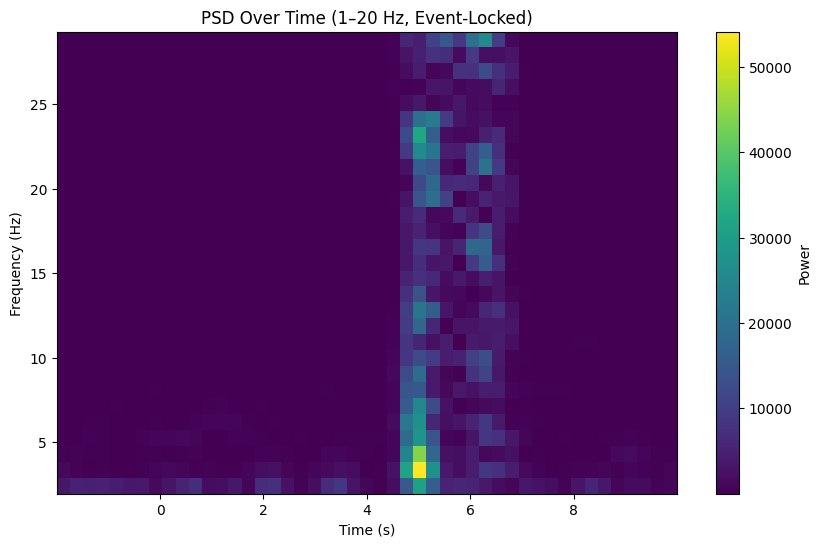

In [217]:
from mne.time_frequency import stft
import numpy as np
import matplotlib.pyplot as plt

# --- STFT ---
data = window_mne.get_data()  # (n_channels, n_times)
n_fft = 256
step = 64

Zxx = stft(data, wsize=n_fft, tstep=step)   # (n_channels, n_freqs, n_windows)
power = np.abs(Zxx) ** 2

# --- Build time & freq axes ---
mne_time = np.array(raw_windows[2]["t_rel"])
times = np.linspace(mne_time[0], mne_time[-1], power.shape[-1])
freqs = np.linspace(0, window_mne.info['sfreq'] / 2, power.shape[1])

# --- Select 1–20 Hz ---
freq_mask = (freqs >= 1) & (freqs <= 30)
freqs_1_20 = freqs[freq_mask]
power_1_20 = power[:, freq_mask, :]   # apply mask to power

# --- Average across channels ---
psd_avg = power_1_20.mean(axis=0)     # shape: (freqs_1_20, times)

# --- Plot ---
plt.figure(figsize=(10,6))
plt.imshow(
    psd_avg,
    aspect='auto',
    origin='lower',
    extent=[times[0], times[-1], freqs_1_20[0], freqs_1_20[-1]]
)
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("PSD Over Time (1–20 Hz, Event-Locked)")
plt.colorbar(label="Power")
plt.show()


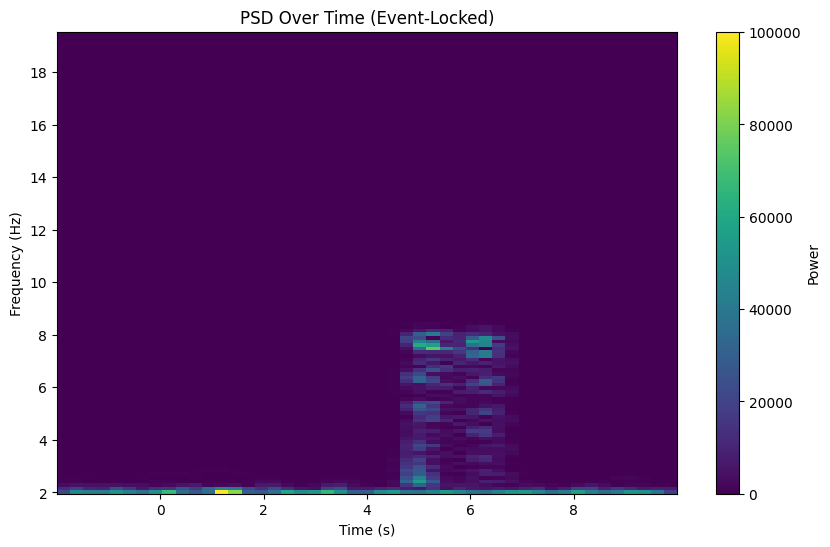

In [213]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.imshow(
    psd_avg,
    aspect='auto',
    origin='lower',
    extent=[times[0], times[-1], freqs[0], freqs[-1]]
)
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("PSD Over Time (Event-Locked)")
plt.colorbar(label="Power")
plt.show()


In [161]:
# PSD DATA ANALYSIS
# Part 1: percent change pre and post trigger

fs = 250
prev = 2
posts = 10
pre_window = int(prev*fs)
post_window = int(posts* fs)
eeg_filt = pd.DataFrame(window_mne.get_data().copy()).T
#target_timestamp
pre_segments = []
post_segments  = []
pre_segments.append(eeg_filt.iloc[:pre_window])
post_segments.append(eeg_filt.iloc[post_window:])

In [162]:
from scipy.signal import welch
import numpy as np

def compute_psd(seg):
    f, psd = welch(seg, fs=fs, nperseg=fs, axis=0)
    return f, psd  # psd shape: freqs × channels
pre_psds  = []
post_psds = []

for pre, post in zip(pre_segments, post_segments):
    f, pre_psd  = compute_psd(pre)
    f, post_psd = compute_psd(post)
    pre_psds.append(pre_psd)
    post_psds.append(post_psd)
pre_psd_mean  = np.mean(pre_psds, axis=0)
post_psd_mean = np.mean(post_psds, axis=0)


In [163]:
percent_change_psd = (post_psd_mean - pre_psd_mean) / pre_psd_mean * 100
percent_change_psd = pd.DataFrame(percent_change_psd)
percent_change_psd

,0,1,2,3,4,5,6
0,-82.761089,9.116404,951.009723,440.578451,-35.249906,-52.603626,-44.198245
1,-82.391897,-22.909407,177.470262,29.639313,-46.655980,-54.467032,-62.910383
2,-84.456630,-38.361203,66.288487,52.091138,-49.114262,-61.708927,-58.410394
3,164.865107,230.667081,12.275367,109.960423,144.404472,128.254345,350.887155
4,41.946050,289.904930,-57.128331,528.091017,185.224624,115.021919,121.359543
...,...,...,...,...,...,...,...
121,-62.215010,-60.595108,-29.556895,-73.849793,-67.248218,-62.153998,-77.456495
122,-66.105295,-70.017187,-34.588514,-83.532836,-74.069934,-69.127067,-82.278752
123,-67.408804,-69.663787,-43.960968,-82.893008,-74.898831,-70.303692,-83.069586
124,-65.777427,-69.685703,-51.003955,-81.673942,-74.298904,-70.561197,-80.118934


In [164]:
def band_power(psd, freqs, f_lo, f_hi):
    idx = (freqs >= f_lo) & (freqs <= f_hi)
    return np.trapz(psd[idx, :], freqs[idx], axis=0)
# Theta (4–7 Hz)
pre_theta  = band_power(pre_psd_mean,  f, 4, 7)
post_theta = band_power(post_psd_mean, f, 4, 7)

# Alpha (8–12 Hz)
pre_alpha  = band_power(pre_psd_mean,  f, 8, 12)
post_alpha = band_power(post_psd_mean, f, 8, 12)

# Beta (13–30 Hz)
pre_beta  = band_power(pre_psd_mean,  f, 13, 30)
post_beta = band_power(post_psd_mean, f, 13, 30)

# Gamma (30-40Hz)
pre_gamma = band_power(pre_psd_mean,  f, 30, 40)
post_gamma = band_power(post_psd_mean, f, 30, 40)


theta_pct = (post_theta - pre_theta) / pre_theta * 100
alpha_pct = (post_alpha - pre_alpha) / pre_alpha * 100
beta_pct  = (post_beta  - pre_beta ) / pre_beta  * 100
gamma_pct =  (post_gamma  - pre_gamma ) / pre_gamma  * 100

bands_pct_df = pd.DataFrame({
    "Theta %Δ": theta_pct,
    "Alpha %Δ": alpha_pct,
    "Beta %Δ":  beta_pct,
    "Gamma %Δ" : gamma_pct,
})
bands_pct_df.index = [f"Ch{i+1}" for i in range(7)]
bands_pct_df


,Theta %Δ,Alpha %Δ,Beta %Δ,Gamma %Δ
Ch1,-6.472544,25.805821,-32.458087,-17.956467
Ch2,75.789035,99.348100,10.293526,19.050524
Ch3,-20.188681,-22.656537,-18.792053,8.358967
Ch4,45.363112,21.633472,12.851090,34.330070
Ch5,45.164777,75.109925,-0.898577,21.555353
Ch6,22.255990,67.400121,-2.775677,7.345860
Ch7,52.107507,168.309611,-8.761430,19.147371
